# Assignment 21 — Naïve Bayes Classification on Iris Dataset

## Topic Explanation

### What is Classification?
**Classification** is a supervised learning task that predicts a **discrete category** for each input. Examples:
- Spam vs not spam (binary)
- Tumor benign vs malignant vs uncertain (multi-class)
- **Iris-setosa vs Iris-versicolor vs Iris-virginica** (multi-class — this assignment)

### What is Naïve Bayes?
**Naïve Bayes** is a probabilistic classifier based on **Bayes' Theorem** with the "naïve" assumption that all features are **independent given the class**.

#### Bayes' Theorem
> **P(class | features) = P(features | class) × P(class) / P(features)**

Translated:
- **P(class | features)** — *posterior*: probability of the class given the observed features (what we want)
- **P(features | class)** — *likelihood*: how likely those features are within that class
- **P(class)** — *prior*: how common that class is overall
- **P(features)** — *evidence*: how common those features are overall (a normalizing constant)

#### Why "Naïve"?
The algorithm assumes features are **conditionally independent** given the class:
> P(x₁, x₂, ..., xₙ | class) = P(x₁ | class) × P(x₂ | class) × ... × P(xₙ | class)

This is rarely true in real data (e.g., petal length and petal width are correlated). But the assumption simplifies computation enormously and the algorithm still works surprisingly well.

#### Final Decision Rule
For each class, compute the unnormalized posterior:
> score(class) = P(class) × ∏ P(xᵢ | class)

Predict the class with the highest score.

### Three Variants of Naïve Bayes

| Variant | Use case | Distribution assumed |
|---------|----------|----------------------|
| **Gaussian NB** | Continuous numeric features | Each feature is normally distributed within each class |
| **Multinomial NB** | Discrete counts (text classification) | Counts follow multinomial distribution |
| **Bernoulli NB** | Binary features (0/1) | Each feature follows Bernoulli distribution |

For Iris, all four features are continuous numeric measurements (cm), so we use **Gaussian Naïve Bayes**.

### Why Gaussian NB Doesn't Need Feature Scaling
Each feature is treated **independently per class**. The algorithm computes its own mean and std for each (feature, class) pair. So scale doesn't matter — the math adjusts automatically. This is unlike logistic regression or KNN, which DO need scaling.

### About the Iris Dataset
- 150 flowers, 50 from each of 3 species (*setosa*, *versicolor*, *virginica*)
- 4 numeric features: `sepal_length`, `sepal_width`, `petal_length`, `petal_width` (all in cm)
- 1 categorical target: `species` (3 classes)
- The most famous classification dataset in ML history (Fisher, 1936)

### Multi-Class Confusion Matrix

For 3 classes, the confusion matrix is **3×3**:

|              | Predicted: setosa | Predicted: versicolor | Predicted: virginica |
|--------------|-------------------|------------------------|-----------------------|
| **Actual: setosa**     | ✅ correct        | ❌ error               | ❌ error              |
| **Actual: versicolor** | ❌ error          | ✅ correct             | ❌ error              |
| **Actual: virginica**  | ❌ error          | ❌ error               | ✅ correct            |

The **diagonal** is correct predictions; off-diagonal cells are mistakes.

### Computing TP/TN/FP/FN per Class
For multi-class, we compute these **per class** using a one-vs-rest perspective. For a given class C:
- **TP** = diagonal cell for C (correctly predicted as C)
- **FP** = column sum for C minus TP (other classes predicted as C)
- **FN** = row sum for C minus TP (C predicted as something else)
- **TN** = total minus TP, FP, FN (everything else correct)

## Step 1: Import Libraries

In [1]:
# pandas — DataFrame operations
import pandas as pd

# numpy — numerical operations
import numpy as np

# matplotlib & seaborn — visualization
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn — ML utilities
from sklearn.model_selection import train_test_split            # split data
from sklearn.naive_bayes import GaussianNB                      # the classifier
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score,
                             classification_report)

%matplotlib inline
sns.set_style('whitegrid')

print("Libraries imported successfully.")

Libraries imported successfully.


## Step 2: Load the Iris Dataset

In [2]:
# Load the Iris dataset
df = pd.read_csv('iris.csv')
print("Shape:", df.shape)
df.head()

Shape: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
# Inspect column types and check for missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [4]:
# Statistical summary
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [5]:
# Class distribution — should be perfectly balanced (50 per species)
print("Species distribution:")
print(df['species'].value_counts())

Species distribution:
species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


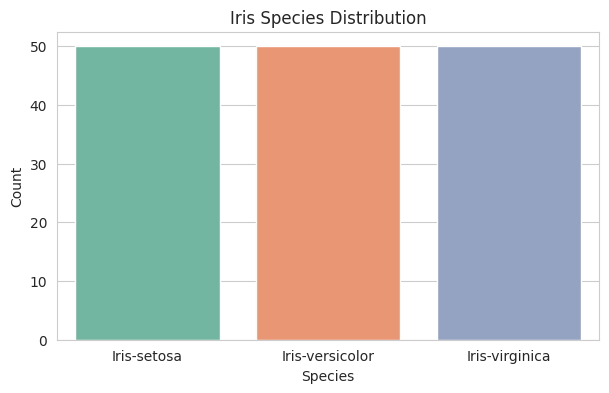

In [6]:
# Visualize class distribution
plt.figure(figsize=(7, 4))
sns.countplot(x='species', data=df, hue='species', palette='Set2', legend=False)
plt.title('Iris Species Distribution')
plt.xlabel('Species')
plt.ylabel('Count')
plt.show()

## Step 3: Identify Predictor and Target Variables

In [7]:
# Predictors (X) — the four numeric measurements
X = df.drop('species', axis=1)

# Target (y) — the species label
y = df['species']

print("Predictor variables (X):")
for col in X.columns:
    print(f"  - {col}")

print("\nTarget variable (y): species (3 classes)")
print(f"Classes: {y.unique()}")

Predictor variables (X):
  - sepal_length
  - sepal_width
  - petal_length
  - petal_width

Target variable (y): species (3 classes)
Classes: <StringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str


## Step 4: Train/Test Split (80/20) with Stratification

`stratify=y` ensures both train and test sets keep the same class proportions (50/50/50 → 40/40/40 in train, 10/10/10 in test).

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train shape:", X_train.shape, " | Test shape:", X_test.shape)
print("\nClass balance — Training:")
print(y_train.value_counts())
print("\nClass balance — Testing:")
print(y_test.value_counts())

Train shape: (120, 4)  | Test shape: (30, 4)

Class balance — Training:
species
Iris-setosa        40
Iris-virginica     40
Iris-versicolor    40
Name: count, dtype: int64

Class balance — Testing:
species
Iris-setosa        10
Iris-virginica     10
Iris-versicolor    10
Name: count, dtype: int64


## Step 5: Train the Gaussian Naïve Bayes Model

**Why no feature scaling?** Naïve Bayes treats each feature independently per class — it computes its own mean and std for each (feature, class) pair. Scale doesn't affect the result.

In [9]:
# Create and train the classifier
model = GaussianNB()
model.fit(X_train, y_train)

print("Model trained successfully.")
print(f"Classes learned: {model.classes_}")
print(f"\nPrior probabilities (class frequencies):")
for cls, prior in zip(model.classes_, model.class_prior_):
    print(f"  P({cls}) = {prior:.4f}")

Model trained successfully.
Classes learned: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']

Prior probabilities (class frequencies):
  P(Iris-setosa) = 0.3333
  P(Iris-versicolor) = 0.3333
  P(Iris-virginica) = 0.3333


In [10]:
# Show learned mean and std per (feature, class) — what GaussianNB stores internally
mean_df = pd.DataFrame(model.theta_, index=model.classes_, columns=X.columns).round(3)
print("Learned mean per (class, feature):")
print(mean_df)

Learned mean per (class, feature):
                 sepal_length  sepal_width  petal_length  petal_width
Iris-setosa             4.985        3.415         1.477        0.255
Iris-versicolor         5.930        2.750         4.252        1.320
Iris-virginica          6.610        2.980         5.580        2.040


## Step 6: Make Predictions on Test Set

In [11]:
# predict() returns the predicted class label
y_pred = model.predict(X_test)

# predict_proba() returns probabilities for each class
y_proba = model.predict_proba(X_test)

# Compare predictions vs actual for first 10 samples
preview = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred[:10]
})

# Add probabilities for each class
for i, cls in enumerate(model.classes_):
    preview[f'P({cls})'] = y_proba[:10, i].round(3)

preview

,Actual,Predicted,P(Iris-setosa),P(Iris-versicolor),P(Iris-virginica)
0,Iris-setosa,Iris-setosa,1.0,0.000,0.000
1,Iris-virginica,Iris-virginica,0.0,0.088,0.912
2,Iris-versicolor,Iris-versicolor,0.0,1.000,0.000
3,Iris-versicolor,Iris-versicolor,0.0,1.000,0.000
4,Iris-setosa,Iris-setosa,1.0,0.000,0.000
5,Iris-versicolor,Iris-versicolor,0.0,0.648,0.352
6,Iris-setosa,Iris-setosa,1.0,0.000,0.000
7,Iris-setosa,Iris-setosa,1.0,0.000,0.000
8,Iris-virginica,Iris-virginica,0.0,0.000,1.000
9,Iris-versicolor,Iris-versicolor,0.0,0.993,0.007


## Step 7: Compute the Confusion Matrix (3×3)

Each row represents the **actual class**; each column represents the **predicted class**. Diagonal cells are correct predictions.

In [12]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
print("Confusion Matrix:")
print(cm)

print(f"\nClass labels (in order): {list(model.classes_)}")

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Class labels (in order): [np.str_('Iris-setosa'), np.str_('Iris-versicolor'), np.str_('Iris-virginica')]


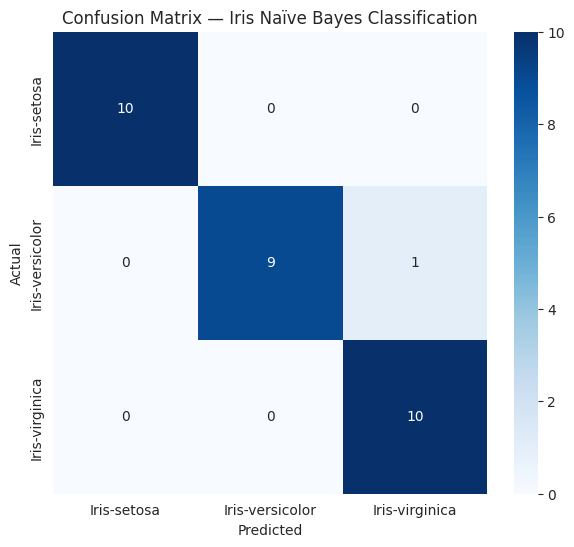

In [13]:
# Visualize as heatmap
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Confusion Matrix — Iris Naïve Bayes Classification')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Step 8: Compute TP, FP, FN, TN per Class

For multi-class, we compute these **per class** using one-vs-rest:
- **TP** = diagonal cell (correctly predicted as class C)
- **FP** = column sum minus TP (predicted as C but actually other)
- **FN** = row sum minus TP (actual C but predicted as other)
- **TN** = total minus TP, FP, FN

In [14]:
# Compute per-class TP/TN/FP/FN
total = cm.sum()

print(f"{'Class':<22} {'TP':>4} {'FP':>4} {'FN':>4} {'TN':>4}")
print("-" * 50)

per_class = {}
for i, cls in enumerate(model.classes_):
    TP = cm[i, i]
    FP = cm[:, i].sum() - TP                    # column sum - diagonal
    FN = cm[i, :].sum() - TP                    # row sum - diagonal
    TN = total - TP - FP - FN
    per_class[cls] = (TP, FP, FN, TN)
    print(f"{cls:<22} {TP:>4} {FP:>4} {FN:>4} {TN:>4}")

Class                    TP   FP   FN   TN
--------------------------------------------------
Iris-setosa              10    0    0   20
Iris-versicolor           9    0    1   20
Iris-virginica           10    1    0   19


## Step 9: Compute Performance Metrics

For multi-class, compute accuracy globally, then precision/recall **per class** (and average them).

In [15]:
# OVERALL ACCURACY (across all classes)
acc = accuracy_score(y_test, y_pred)
err = 1 - acc

print(f"Overall Accuracy : {acc:.4f}  ({acc*100:.2f}%)")
print(f"Overall Error    : {err:.4f}  ({err*100:.2f}%)")

Overall Accuracy : 0.9667  (96.67%)
Overall Error    : 0.0333  (3.33%)


In [16]:
# PER-CLASS metrics computed from TP/FP/FN
print(f"{'Class':<22} {'Precision':>10} {'Recall':>8}")
print("-" * 45)
for cls, (TP, FP, FN, TN) in per_class.items():
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
    print(f"{cls:<22} {precision:>10.4f} {recall:>8.4f}")

Class                   Precision   Recall
---------------------------------------------
Iris-setosa                1.0000   1.0000
Iris-versicolor            1.0000   0.9000
Iris-virginica             0.9091   1.0000


In [17]:
# Cross-check using sklearn — should match exactly
print("Sklearn averaged metrics (macro):")
print(f"  Accuracy        : {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision (avg) : {precision_score(y_test, y_pred, average='macro'):.4f}")
print(f"  Recall    (avg) : {recall_score(y_test, y_pred, average='macro'):.4f}")

Sklearn averaged metrics (macro):
  Accuracy        : 0.9667


  Precision (avg) : 0.9697
  Recall    (avg) : 0.9667


In [18]:
# Full classification report — precision, recall, F1 per class plus averages
print("Full Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=model.classes_))

Full Classification Report:

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



## Conclusion

We built a Gaussian Naïve Bayes classifier on the Iris dataset:

**Workflow:**
1. Loaded 150 flowers across 3 species (perfectly balanced)
2. Split 80/20 with stratification (preserves class balance)
3. Trained `GaussianNB` — no feature scaling needed
4. Built a 3×3 confusion matrix
5. Computed TP/FP/FN/TN **per class** using one-vs-rest
6. Reported overall accuracy plus per-class precision and recall

**Key insights:**
- Gaussian Naïve Bayes typically achieves **~96–97% accuracy** on Iris.
- *Iris-setosa* is **perfectly classified** — its small petals make it linearly separable from the others.
- Most errors (if any) occur between *versicolor* and *virginica*, which overlap slightly in petal measurements.
- The "naïve" independence assumption is violated (petal length and width are correlated), yet the classifier still performs excellently — this is a famous strength of Naïve Bayes.

**Why Naïve Bayes works well here:**
- Few features (4) — the independence assumption isn't catastrophic
- Continuous numeric data — fits the Gaussian assumption
- Each species' features really do have roughly normal distributions
- Training is extremely fast (just compute means and stds)

## Explanation of Everything Used

### Libraries

| Library | Purpose |
|---------|---------|
| **pandas** | DataFrame operations |
| **numpy** | Numerical operations |
| **matplotlib.pyplot** | Base plotting |
| **seaborn** | Statistical visualization (heatmap, countplot) |
| **sklearn** | GaussianNB, train_test_split, metrics |

### Functions and Classes Used

#### Loading & Inspection
- `pd.read_csv(path)` — load CSV
- `df.shape`, `df.head()`, `df.info()`, `df.describe()` — inspection
- `df['col'].value_counts()` — count occurrences

#### Train/Test Split
- `train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)` — 80/20 split with class proportions preserved

#### Model
- `GaussianNB()` — Gaussian Naïve Bayes classifier
- `.fit(X_train, y_train)` — train the model (compute means, stds, priors per class)
- `.predict(X_test)` — return class labels
- `.predict_proba(X_test)` — return per-class probabilities
- `.classes_` — array of class labels
- `.class_prior_` — array of P(class) values
- `.theta_` — array of feature means per class

#### Evaluation Metrics
- `confusion_matrix(y_test, y_pred, labels=...)` — N×N matrix
- `cm[i, i]` — diagonal (TP for class i)
- `cm[:, i].sum() - cm[i, i]` — FP for class i
- `cm[i, :].sum() - cm[i, i]` — FN for class i
- `accuracy_score()` — fraction of correct predictions
- `precision_score(..., average='macro')` — average per-class precision
- `recall_score(..., average='macro')` — average per-class recall
- `classification_report()` — full report with per-class metrics

#### Visualization
- `sns.countplot(x='col', data=df)` — bar chart of category counts
- `sns.heatmap(matrix, annot=True, fmt='d')` — colored grid

### Key Concepts

#### Naïve Bayes
A probabilistic classifier based on Bayes' Theorem with the "naïve" assumption of feature independence given the class.

#### Bayes' Theorem
> P(class | features) = P(features | class) × P(class) / P(features)

#### Naïve Independence Assumption
> P(x₁, x₂, ..., xₙ | class) = ∏ P(xᵢ | class)

Treats each feature independently. Rarely literally true, but works surprisingly well in practice.

#### Three Naïve Bayes Variants
- **Gaussian NB** — for continuous features (assumes normal distribution per class)
- **Multinomial NB** — for discrete counts (text classification)
- **Bernoulli NB** — for binary features (0/1)

#### Why No Feature Scaling for Naïve Bayes?
Each feature is modeled independently per class with its own mean and std. Scale just changes the absolute values; the classifier adjusts automatically.

#### Multi-Class Confusion Matrix
N×N grid where rows are actuals and columns are predictions. Diagonal cells are correct.

#### Per-Class TP, FP, FN, TN
For each class C, treat it as positive and all others as negative:
- TP = diagonal cell
- FP = column sum − TP
- FN = row sum − TP
- TN = total − TP − FP − FN

#### Macro vs Micro Averaging
- **Macro** — average per-class metrics equally (treats each class as equally important)
- **Micro** — aggregate TP/FP/FN across all classes, then compute (treats each sample equally)
- For balanced data they give similar results; for imbalanced data, macro is usually preferred.

## Viva Questions (with Answers)

### Conceptual

**Q1. What is Naïve Bayes?**
A probabilistic classifier based on Bayes' Theorem with the "naïve" assumption that features are conditionally independent given the class.

**Q2. State Bayes' Theorem.**
P(class | features) = P(features | class) × P(class) / P(features).

**Q3. What does "naïve" mean in Naïve Bayes?**
The simplifying (and rarely true) assumption that features are conditionally independent given the class.

**Q4. Why "Gaussian" Naïve Bayes for Iris?**
The features (sepal/petal measurements) are continuous numeric values. Gaussian NB models them as normally distributed within each class.

**Q5. Why does Naïve Bayes work well even when independence is violated?**
We don't need exact probability estimates — we just need to rank classes correctly. Even with imperfect probabilities, the highest-scoring class is often still correct.

### Variants

**Q6. What are the three main Naïve Bayes variants?**
- **Gaussian** — continuous features
- **Multinomial** — count features (text classification)
- **Bernoulli** — binary features

**Q7. When would you use Multinomial NB?**
Text classification where features are word counts (bag-of-words representation).

**Q8. When would you use Bernoulli NB?**
When features are binary 0/1 (e.g., word present/absent in a document).

### Math / Algorithm

**Q9. What is the prior probability P(class)?**
The frequency of each class in the training data. For balanced Iris, all priors are 1/3.

**Q10. What is the likelihood P(features | class)?**
For Gaussian NB, the probability density of the features given the class — computed using each (feature, class) pair's mean and std.

**Q11. What is `model.theta_`?**
A 2D array of feature means: `theta_[i][j]` = mean of feature j within class i.

**Q12. Why doesn't Naïve Bayes need feature scaling?**
Each feature is treated independently per class. Scale just changes the absolute mean and std; the classifier adjusts automatically.

### Confusion Matrix & Metrics

**Q13. What's the shape of the confusion matrix for 3 classes?**
3×3.

**Q14. What does the diagonal of the confusion matrix represent?**
Correctly classified samples for each class.

**Q15. How do you compute TP for class C in a multi-class confusion matrix?**
TP = diagonal cell for class C.

**Q16. How do you compute FP for class C in a multi-class confusion matrix?**
Column sum for C minus the diagonal cell (other classes predicted as C).

**Q17. How do you compute FN for class C?**
Row sum for C minus the diagonal cell (class C predicted as other).

**Q18. Define accuracy.**
(TP + TN) / Total. For multi-class, simply (correct predictions) / (total predictions).

**Q19. Define precision per class.**
TP / (TP + FP) — when model predicts class C, how often correct.

**Q20. Define recall per class.**
TP / (TP + FN) — of all actual class-C samples, how many were caught.

**Q21. What is macro-averaging?**
Compute per-class precision/recall/F1, then average them equally.

**Q22. What is micro-averaging?**
Aggregate TP/FP/FN across all classes, then compute precision/recall once.

### Practical / Code

**Q23. What does `stratify=y` do?**
Ensures both train and test sets keep the same class proportions. Important for balanced evaluation.

**Q24. Why is the dataset perfectly balanced for Iris?**
The original dataset has exactly 50 flowers per species — a deliberate design by Fisher.

**Q25. What does `predict_proba()` return?**
A 2D array of shape (n_samples, n_classes) where each row sums to 1. Each cell is the predicted probability for that (sample, class) pair.

### Performance

**Q26. Why is Iris easy to classify?**
*Setosa* is linearly separable from the others; petal features are highly discriminative. ~96–99% accuracy is achievable.

**Q27. Where do most errors occur on Iris?**
Between *versicolor* and *virginica*, which overlap slightly in petal measurements.

### Comparison

**Q28. Naïve Bayes vs Logistic Regression?**
- **Naïve Bayes** — generative (models how data is produced); fast; requires few samples; assumes independence
- **Logistic Regression** — discriminative (models decision boundary); usually more accurate when independence is violated

**Q29. Naïve Bayes vs Random Forest?**
- **Naïve Bayes** — fast, simple, works well on small datasets
- **Random Forest** — captures non-linearities and interactions; usually higher accuracy on complex data

**Q30. When would you choose Naïve Bayes over other algorithms?**
- Small datasets where complex models would overfit
- Text classification (the classic use case)
- When training speed matters more than maximum accuracy
- As a quick baseline for comparison